##  Basic Library imports

In [2]:
import os
import pandas as pd 
import numpy as np
import csv
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import chi2
import re
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, f1_score, accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns     

##  Read Dataset

In [3]:
DATASET_FOLDER = '../dataset/'
train = pd.read_csv(os.path.join(DATASET_FOLDER, 'train.csv'))
test = pd.read_csv(os.path.join(DATASET_FOLDER, 'test.csv'))
sample_test = pd.read_csv(os.path.join(DATASET_FOLDER, 'sample_test.csv'))
sample_test_out = pd.read_csv(os.path.join(DATASET_FOLDER, 'sample_test_out.csv'))

In [ ]:
from utils import download_images
download_images(sample_test['image_link'], '../images')


Exception in thread Thread-3 (_handle_workers):
Traceback (most recent call last):
  File "C:\Users\DELL\AppData\Local\Programs\Python\Python312\Lib\threading.py", line 1075, in _bootstrap_inner
    self.run()
  File "c:\Users\DELL\Downloads\68e8d1d70b66d_student_resource\student_resource\venv\Lib\site-packages\ipykernel\ipkernel.py", line 772, in run_closure
    _threading_Thread_run(self)
  File "C:\Users\DELL\AppData\Local\Programs\Python\Python312\Lib\threading.py", line 1012, in run
    self._target(*self._args, **self._kwargs)
  File "C:\Users\DELL\AppData\Local\Programs\Python\Python312\Lib\multiprocessing\pool.py", line 522, in _handle_workers
    cls._wait_for_updates(current_sentinels, change_notifier)
  File "C:\Users\DELL\AppData\Local\Programs\Python\Python312\Lib\multiprocessing\pool.py", line 502, in _wait_for_updates
    wait(sentinels, timeout=timeout)
  File "C:\Users\DELL\AppData\Local\Programs\Python\Python312\Lib\multiprocessing\connection.py", line 1084, in wait
 

In [ ]:
assert len(os.listdir('../images')) > 0

In [ ]:
rm -rf ../images

## PREPROCESSING AND EDA

In [4]:
DATASET_FOLDER = '../dataset/processed_subset/'
train = pd.read_csv(os.path.join(DATASET_FOLDER, 'train_clean_subset.csv'))
test = pd.read_csv(os.path.join(DATASET_FOLDER, 'test_clean_subset.csv'))

print("DATA LOADED SUCCESSFULLY")

DATA LOADED SUCCESSFULLY


In [5]:
train.info()
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18750 entries, 0 to 18749
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   sample_id        18750 non-null  int64  
 1   catalog_content  18750 non-null  object 
 2   image_link       18750 non-null  object 
 3   price            18750 non-null  float64
 4   clean_text       18750 non-null  object 
dtypes: float64(1), int64(1), object(3)
memory usage: 732.6+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18750 entries, 0 to 18749
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   sample_id        18750 non-null  int64 
 1   catalog_content  18750 non-null  object
 2   image_link       18750 non-null  object
 3   clean_text       18750 non-null  object
dtypes: int64(1), object(3)
memory usage: 586.1+ KB


In [6]:
train.drop_duplicates(inplace=True)
test.drop_duplicates(inplace=True)

In [7]:
train.isnull().sum()
test.isnull().sum()

sample_id          0
catalog_content    0
image_link         0
clean_text         0
dtype: int64

In [8]:
train.dropna(subset=['price'], inplace=True)
train['price'] = pd.to_numeric(train['price'], errors='coerce')

In [10]:
initial_rows = len(train)
train.dropna(subset=['price'], inplace=True)
rows_dropped = initial_rows - len(train)
if rows_dropped > 0:
  print(f"Dropped {rows_dropped} rows with missing prices.")

In [11]:
train['catalog_content'].fillna('Unknown', inplace=True)
test['catalog_content'].fillna('Unknown', inplace=True)

C:\Users\DELL\AppData\Local\Temp\ipykernel_7480\2724207420.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train['catalog_content'].fillna('Unknown', inplace=True)
C:\Users\DELL\AppData\Local\Temp\ipykernel_7480\2724207420.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For

In [12]:
combined_df = pd.concat([train, test], ignore_index=True)

In [13]:
# Extract Brand Name
brand_pattern = r'Item Name: (\w+)'
combined_df['brand'] = combined_df['catalog_content'].str.extract(brand_pattern, expand=False).fillna('unknown')

# Extract Item Pack Quantity (IPQ)
ipq_pattern = r'(\d+)\s*(?:pack|count|oz|fl oz|g|kg|ml|l)'
combined_df['IPQ'] = combined_df['catalog_content'].str.extract(ipq_pattern, flags=re.IGNORECASE).fillna(1)
combined_df['IPQ'] = pd.to_numeric(combined_df['IPQ'], errors='coerce').fillna(1).astype(int)

# Create text-based features
combined_df['word_count'] = combined_df['catalog_content'].apply(lambda x: len(str(x).split()))
combined_df['char_count'] = combined_df['catalog_content'].apply(lambda x: len(str(x)))

# Create 'clean_text' for NLP models
combined_df['clean_text'] = combined_df['catalog_content'].str.lower().str.replace(r'[^a-z0-9\s]', '', regex=True).str.strip()

print("Engineered Features: 'brand', 'IPQ', 'word_count', 'char_count', 'clean_text'")



Engineered Features: 'brand', 'IPQ', 'word_count', 'char_count', 'clean_text'


In [14]:
train_processed = combined_df[combined_df['price'].notna()].copy()
test_processed = combined_df[combined_df['price'].isna()].copy()

Text(0.5, 0, 'Price')

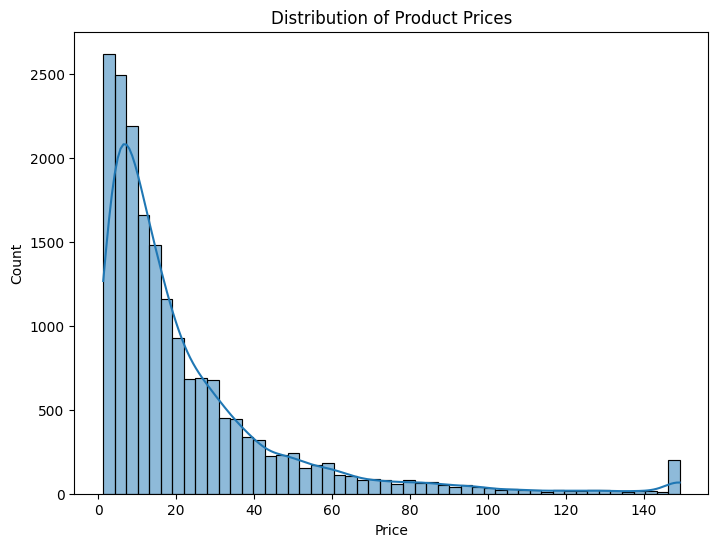

In [15]:
plt.figure(figsize=(18, 6))
plt.subplot(1, 2, 1)
sns.histplot(train_processed['price'], bins=50, kde=True)
plt.title('Distribution of Product Prices')
plt.xlabel('Price')

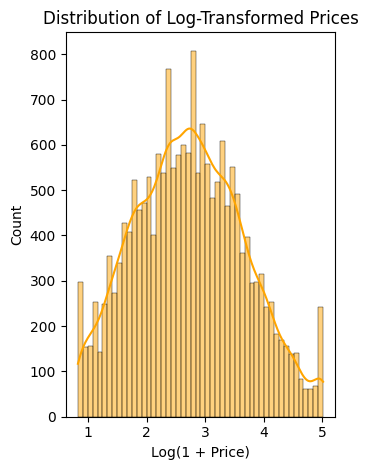

In [16]:
plt.subplot(1, 2, 2)
sns.histplot(np.log1p(train_processed['price']), bins=50, kde=True, color='orange')
plt.title('Distribution of Log-Transformed Prices')
plt.xlabel('Log(1 + Price)')
plt.tight_layout()
plt.show()


--- Correlation Matrix ---
               price       IPQ  word_count  char_count
price       1.000000 -0.005121    0.171737    0.174005
IPQ        -0.005121  1.000000   -0.004439   -0.003777
word_count  0.171737 -0.004439    1.000000    0.997492
char_count  0.174005 -0.003777    0.997492    1.000000


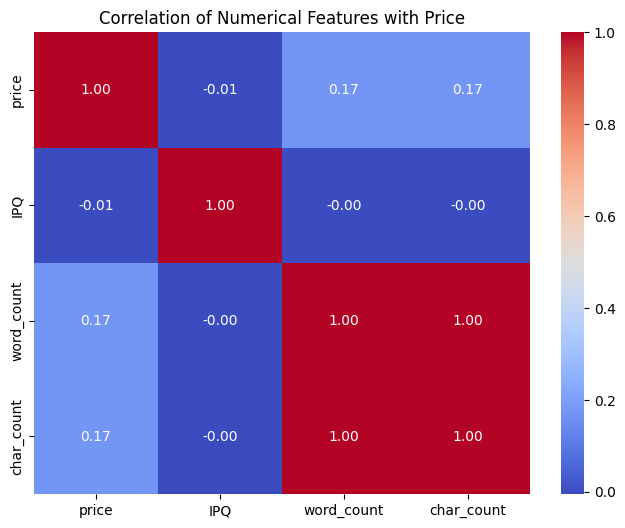

In [17]:
print("\n--- Correlation Matrix ---")
numerical_features = ['price', 'IPQ', 'word_count', 'char_count']
corr_matrix = train_processed[numerical_features].corr()
print(corr_matrix)
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation of Numerical Features with Price')
plt.show()


--- Analyzing Price by Brand (Top 15) ---


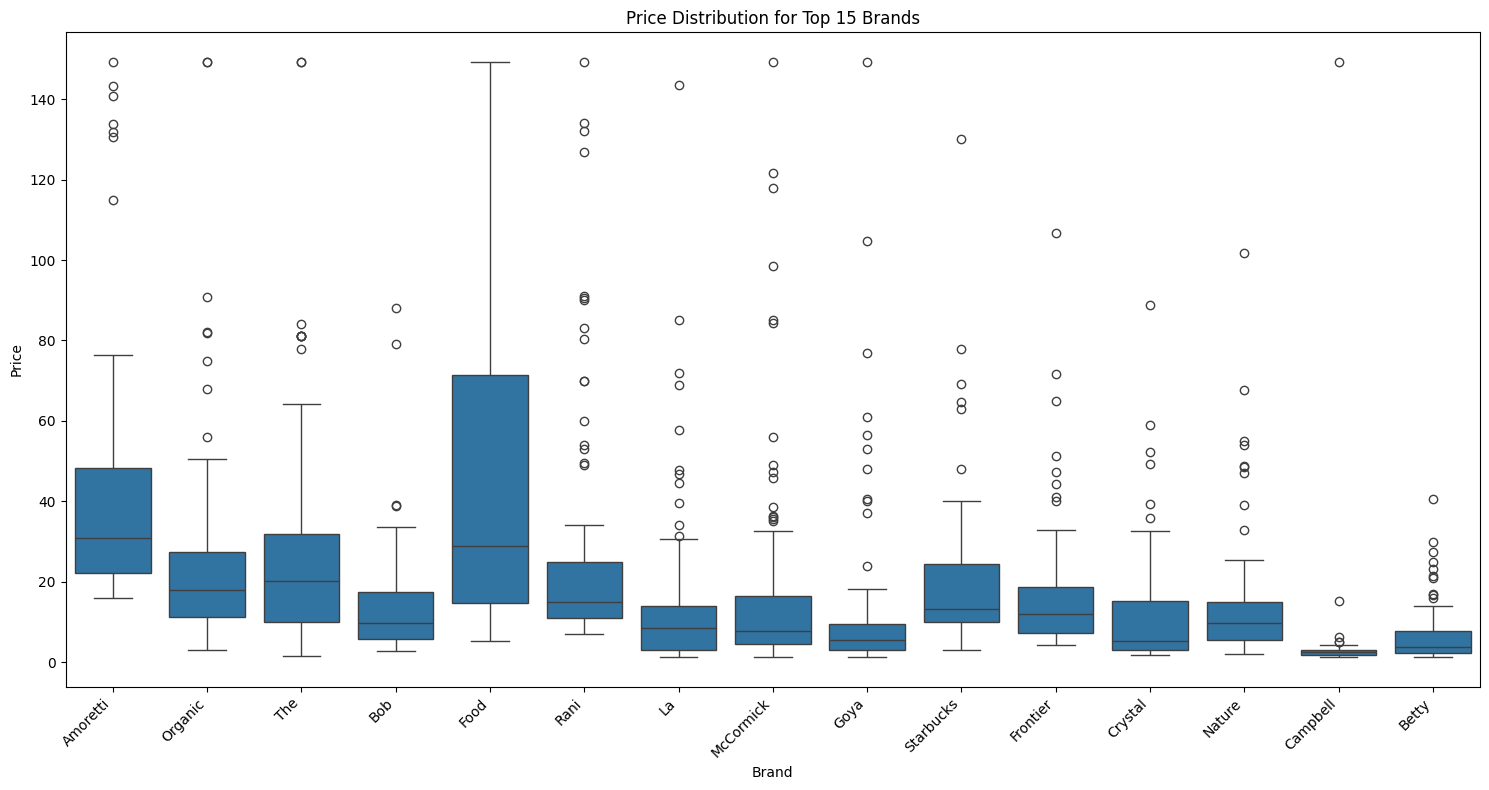


--- Preprocessing and EDA Complete ---


In [18]:
print("\n--- Analyzing Price by Brand (Top 15) ---")
top_brands = train_processed['brand'].value_counts().nlargest(15).index
plt.figure(figsize=(15, 8))
sns.boxplot(data=train_processed[train_processed['brand'].isin(top_brands)], x='brand', y='price')
plt.title('Price Distribution for Top 15 Brands')
plt.xlabel('Brand')
plt.ylabel('Price')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("\n--- Preprocessing and EDA Complete ---")